# Action Potential Dynamics and Oscillations

# Exploration of Differential Equation for Action Potentials

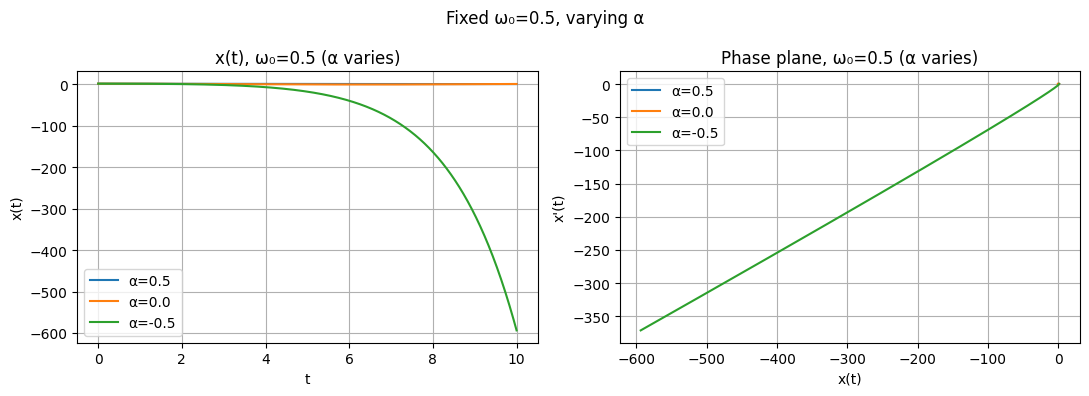

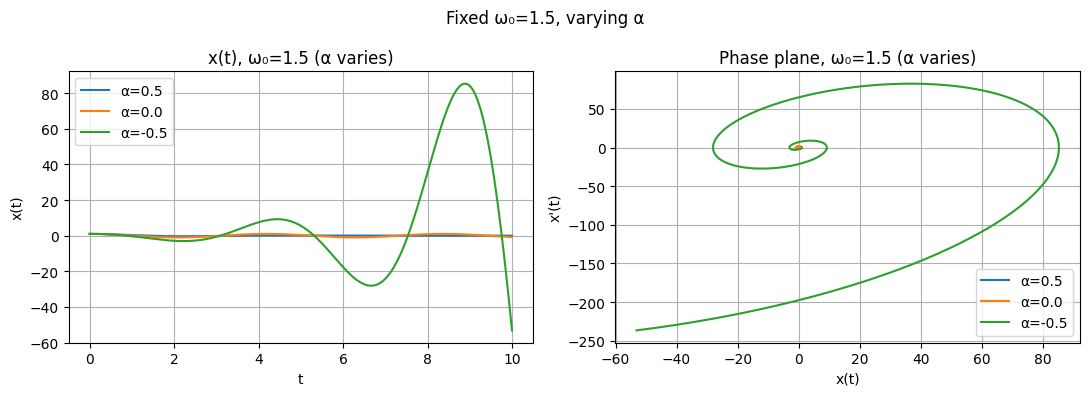

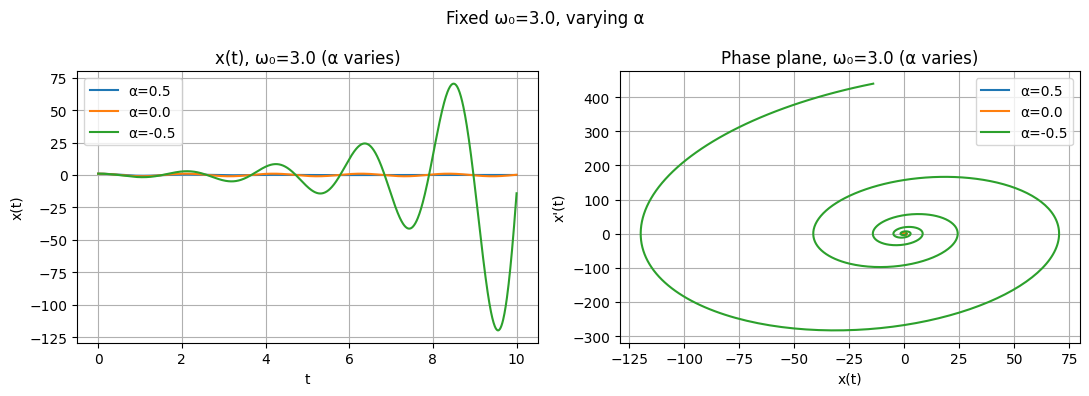

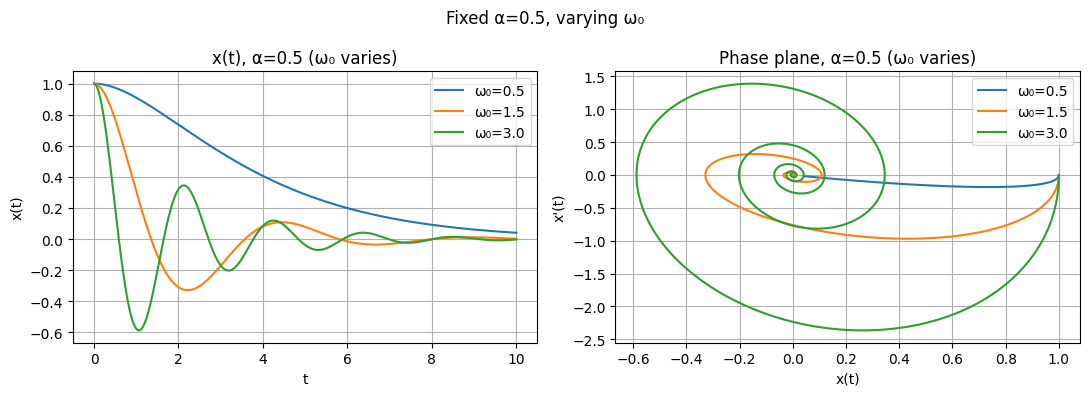

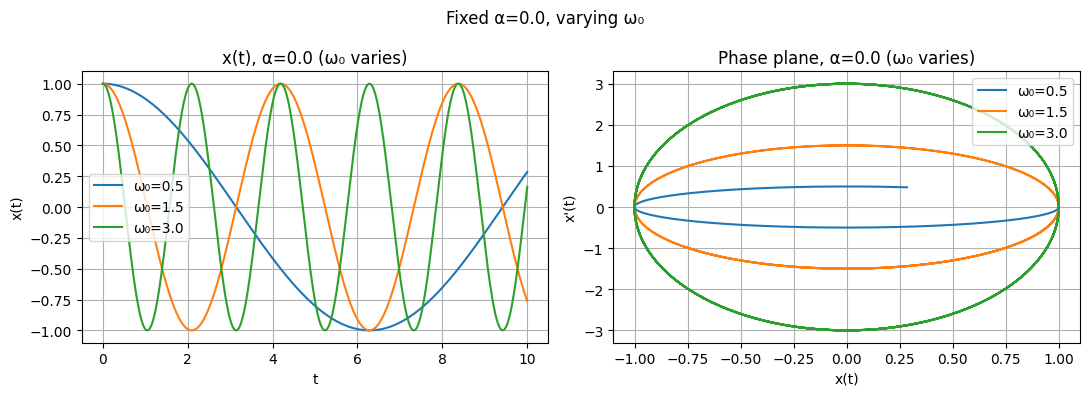

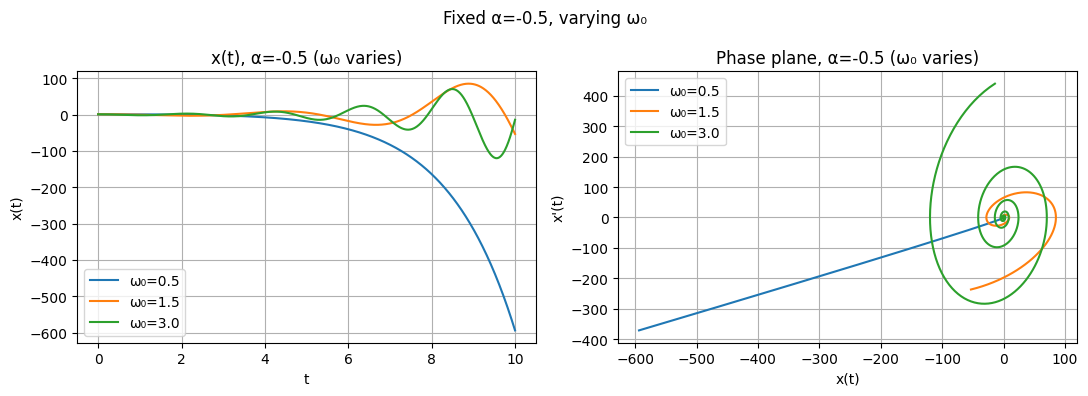

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---- parameters can be changed ----
# vector of alpha values
alpha_vec = [0.5, 0.0, -0.5]      # e.g. α = 0.5, 0, -0.5
# vector of omega0 values
omega_vec = [0.5, 1.5, 3.0]       # this is your [a, b, c]

# time span and initial conditions
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
x0 = 1.0
v0 = 0.0
# -----------------------------------

def oscillator_system(t, y, alpha, omega0):
    x, v = y
    dxdt = v
    dvdt = -2 * alpha * v - (omega0**2) * x
    return [dxdt, dvdt]

# ===========================================================
# 1) Three figures: fixed ω, α varies over alpha_vec
# ===========================================================
for omega0 in omega_vec:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    for alpha in alpha_vec:
        sol = solve_ivp(
            oscillator_system,
            t_span,
            [x0, v0],
            args=(alpha, omega0),
            t_eval=t_eval
        )
        x = sol.y[0]
        v = sol.y[1]

        axes[0].plot(sol.t, x, label=f'α={alpha}')
        axes[1].plot(x, v, label=f'α={alpha}')

    axes[0].set_xlabel('t')
    axes[0].set_ylabel('x(t)')
    axes[0].set_title(f'x(t), ω₀={omega0} (α varies)')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].set_xlabel('x(t)')
    axes[1].set_ylabel("x'(t)")
    axes[1].set_title(f'Phase plane, ω₀={omega0} (α varies)')
    axes[1].legend()
    axes[1].grid(True)

    fig.suptitle(f'Fixed ω₀={omega0}, varying α')
    plt.tight_layout()
    plt.savefig(f"Fixed ω₀={omega0}, varying α.png")  
    plt.show()

# ===========================================================
# 2) Three figures: fixed α, ω varies over omega_vec
# ===========================================================
for alpha in alpha_vec:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    for omega0 in omega_vec:
        sol = solve_ivp(
            oscillator_system,
            t_span,
            [x0, v0],
            args=(alpha, omega0),
            t_eval=t_eval
        )
        x = sol.y[0]
        v = sol.y[1]

        axes[0].plot(sol.t, x, label=f'ω₀={omega0}')
        axes[1].plot(x, v, label=f'ω₀={omega0}')

    axes[0].set_xlabel('t')
    axes[0].set_ylabel('x(t)')
    axes[0].set_title(f'x(t), α={alpha} (ω₀ varies)')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].set_xlabel('x(t)')
    axes[1].set_ylabel("x'(t)")
    axes[1].set_title(f'Phase plane, α={alpha} (ω₀ varies)')
    axes[1].legend()
    axes[1].grid(True)

    fig.suptitle(f'Fixed α={alpha}, varying ω₀')
    plt.tight_layout()
    plt.savefig(f"Fixed α={alpha}, varying ω₀.png")  
    plt.show()




## Objective
The goal of this experiment is to understand how the **damping parameter (α)** and the **natural frequency (ω₀)** influence the behavior of the second-order system:

This model represents oscillations observed in biological action potentials.  
By varying α and ω₀, we can explore **damped**, **undamped**, and **unstable** oscillatory behavior.


## Effect of α (Damping Coefficient)

### 1. α = 0.5 → Damped Oscillations
- The system loses energy over time.
- Amplitude of oscillations decays exponentially.
- Phase-plane trajectories spiral **inward** toward the origin.
- Represents **stable behavior** (energy dissipation).

### 2. α = 0 → Pure Oscillations
- No damping — energy is conserved.
- The system shows **sinusoidal oscillations** of constant amplitude.
- Phase-plane trajectories form **closed ellipses** around the origin.

### 3. α = −0.5 → Unstable (Negative Damping)
- Energy is injected into the system.
- Amplitude **grows exponentially** over time.
- Phase-plane trajectories spiral **outward**, representing **instability**.

**Summary:**  
α determines the **stability** of the system.  
Positive α → decaying motion (stable)  
Zero α → sustained oscillation  
Negative α → diverging motion (unstable)



## Effect of ω₀ (Natural Frequency)

### For α = 0.5 (Damped System)
- Increasing ω₀ results in **faster** oscillations, but all decay over time.
- Phase-plane spirals are tighter for larger ω₀ values.
- System remains stable regardless of ω₀.

### For α = 0.0 (Undamped System)
- Pure oscillations with constant amplitude.
- Larger ω₀ values produce **higher-frequency** oscillations.
- Phase-plane ellipses become narrower (velocity increases with ω₀).

### For α = −0.5 (Unstable System)
- Amplitude increases exponentially for all ω₀ values.
- Higher ω₀ → faster oscillations, but still divergent.
- Phase-plane spirals expand outward with greater rotational speed.



## Combined Interpretation

| Parameter | Physical Meaning | Effect on Dynamics |
|------------|------------------|--------------------|
| **α (damping)** | Energy loss or gain rate | Controls **stability** and **amplitude growth/decay** |
| **ω₀ (natural frequency)** | Restoring force strength | Controls **oscillation speed** and **phase-plane curvature** |

### Key Insights
- **α** controls whether oscillations **decay**, **persist**, or **grow**.
- **ω₀** determines how **fast** the oscillations occur for a given α.
- Together, these parameters shape the stability and temporal patterns of biopotential signals.



## Conclusion
The damping coefficient (α) primarily dictates the **stability** of the system, while the natural frequency (ω₀) determines the **speed** of oscillations.  
Understanding these dynamics provides valuable insight into the generation and control of biological action potentials and synthetic ECG signals.



## Bonus


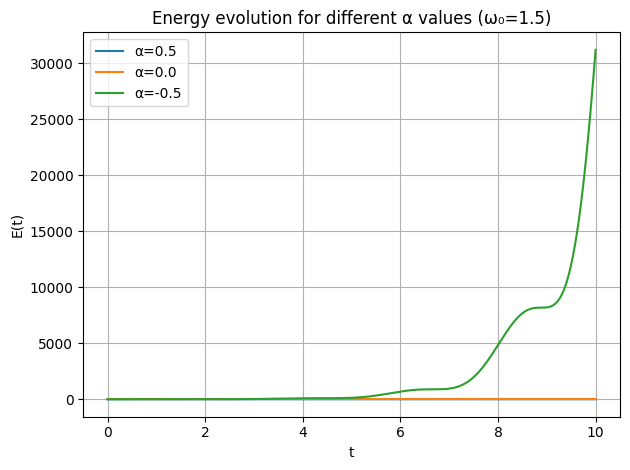

In [17]:
alpha_values = [0.5, 0.0, -0.5]   # damped, neutral, unstable
omega0 = 1.5                    # fixed ω₀
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
x0, v0 = 1.0, 0.0

for alpha in alpha_values:
    sol = solve_ivp(oscillator_system, t_span, [x0, v0], args=(alpha, omega0), t_eval=t_eval)
    x, v = sol.y
    # Energy E(t) = 1/2 v^2 + 1/2 ω₀² x²
    E = 0.5 * v**2 + 0.5 * (omega0**2) * x**2
    plt.plot(sol.t, E, label=f'α={alpha}')

plt.title('Energy evolution for different α values (ω₀=1.5)')
plt.xlabel('t')
plt.ylabel('E(t)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Energy_vs_time.png", dpi=300)
plt.show()

# Van der Pol Oscillator for Self-Regulating Dynamics:

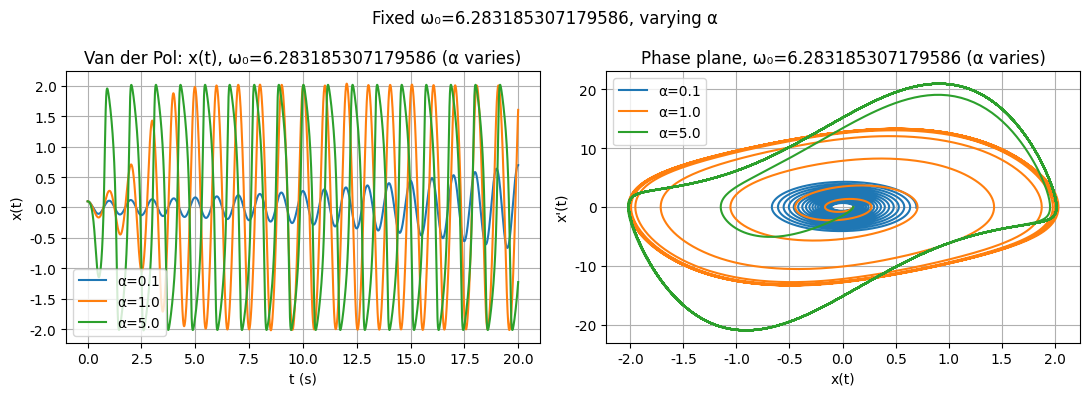

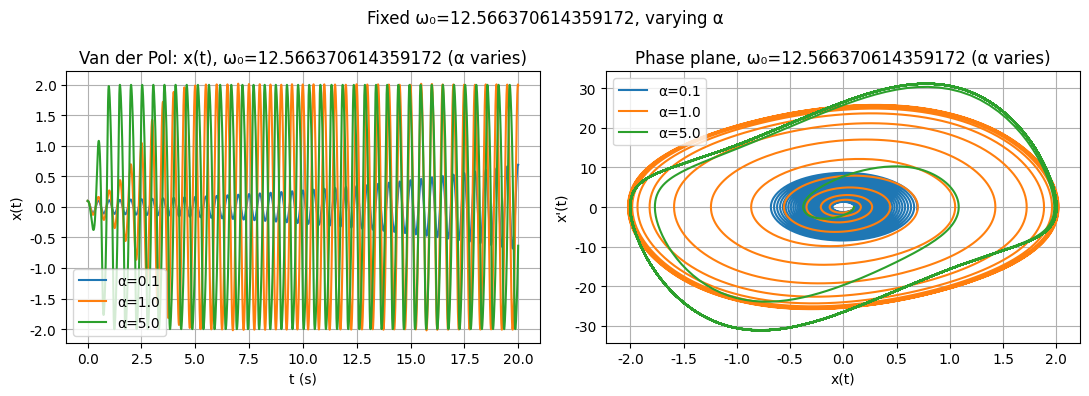

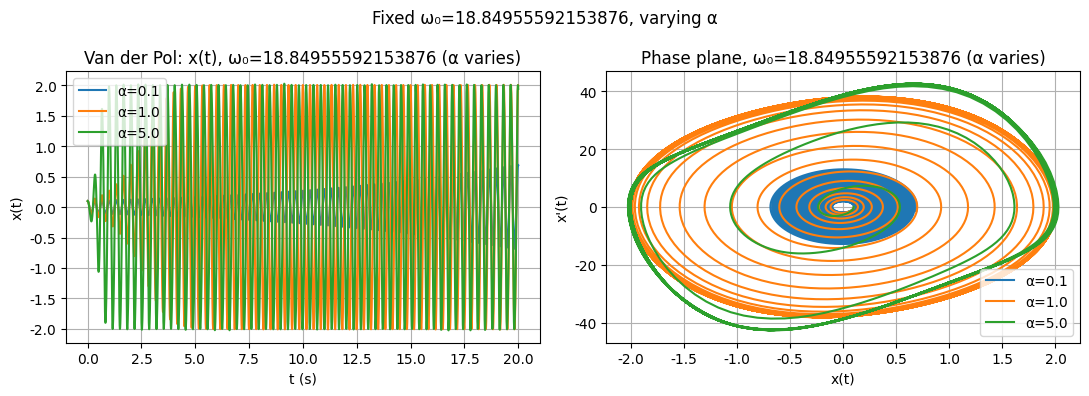

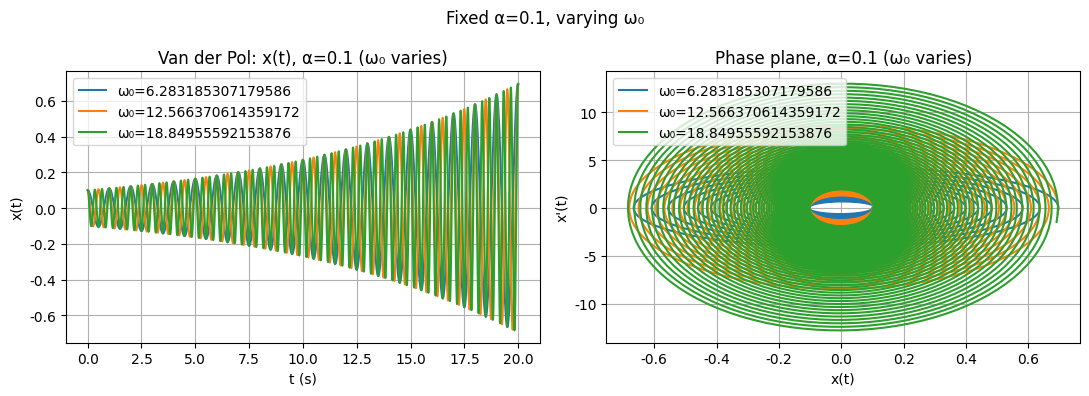

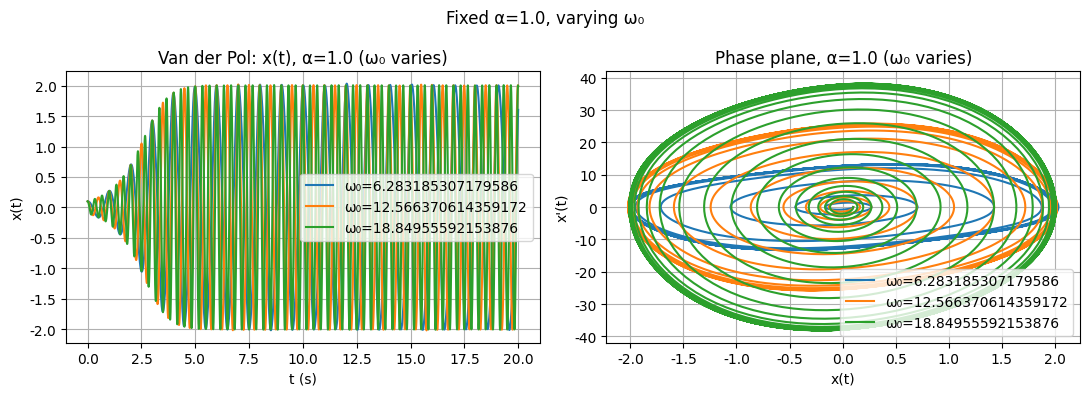

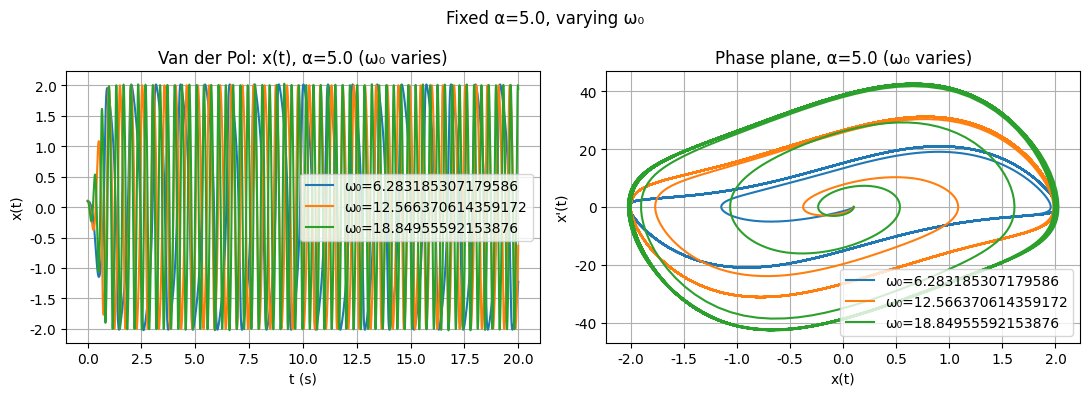

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----------------------------
# parameters to explore
# ----------------------------
alpha_vec = [0.1, 1.0, 5.0]
omega_vec = [2*np.pi, 4*np.pi, 6*np.pi]   # ≈ [6.3, 12.6, 18.9]
idx_vec = [2, 4, 6]   # ≈ [6.3, 12.6, 18.9]

# time span and sampling
t_span = (0, 20)                   # seconds (long enough to reach limit cycle)
t_eval = np.linspace(t_span[0], t_span[1], 6000)

# initial conditions
x0 = 0.1
v0 = 0.0

def vdp_system(t, y, alpha, omega0):
    """
    Van der Pol oscillator in first-order form.
    y[0] = x, y[1] = x'
    """
    x, v = y
    dxdt = v
    dvdt = 2 * alpha * (1 - x**2) * v - (omega0**2) * x
    return [dxdt, dvdt]

# ===========================================================
# 1) Three figures: fixed ω0, α varies over alpha_vec
# ===========================================================
idx = 0
for omega0 in omega_vec:
    
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    for alpha in alpha_vec:
        sol = solve_ivp(
            vdp_system,
            t_span,
            [x0, v0],
            args=(alpha, omega0),
            t_eval=t_eval
        )
        x = sol.y[0]
        v = sol.y[1]

        axes[0].plot(sol.t, x, label=f'α={alpha}')
        axes[1].plot(x, v, label=f'α={alpha}')

    axes[0].set_xlabel('t (s)')
    axes[0].set_ylabel('x(t)')
    axes[0].set_title(f'Van der Pol: x(t), ω₀={omega0} (α varies)')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].set_xlabel('x(t)')
    axes[1].set_ylabel("x'(t)")
    axes[1].set_title(f'Phase plane, ω₀={omega0} (α varies)')
    axes[1].legend()
    axes[1].grid(True)

    fig.suptitle(f'Fixed ω₀={omega0}, varying α')
    plt.tight_layout()
    plt.savefig(f"Fixed w_0 {idx_vec[idx]} pi  varying alpha")
    idx = idx + 1 
    plt.show()

# ===========================================================
# 2) Three figures: fixed α, ω0 varies over omega_vec
# ===========================================================
for alpha in alpha_vec:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    for omega0 in omega_vec:
        sol = solve_ivp(
            vdp_system,
            t_span,
            [x0, v0],
            args=(alpha, omega0),
            t_eval=t_eval
        )
        x = sol.y[0]
        v = sol.y[1]

        axes[0].plot(sol.t, x, label=f'ω₀={omega0}')
        axes[1].plot(x, v, label=f'ω₀={omega0}')

    axes[0].set_xlabel('t (s)')
    axes[0].set_ylabel('x(t)')
    axes[0].set_title(f'Van der Pol: x(t), α={alpha} (ω₀ varies)')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].set_xlabel('x(t)')
    axes[1].set_ylabel("x'(t)")
    axes[1].set_title(f'Phase plane, α={alpha} (ω₀ varies)')
    axes[1].legend()
    axes[1].grid(True)

    fig.suptitle(f'Fixed α={alpha}, varying ω₀')
    plt.tight_layout()
    plt.savefig(f"Fixed alpha {int(10* alpha)} varying w_0")
    plt.show()


##  Conclusion: Van der Pol Oscillator Dynamics

The **Van der Pol oscillator** extends the simple second-order linear model by introducing a **nonlinear damping term** that depends on the system’s state.  
This modification produces **self-regulating oscillations** that can mimic biological action potentials or rhythmic physiological behavior.

---

### Key Observations

- When **α** is small (e.g., 0.1), the system behaves almost linearly, showing **sinusoidal oscillations** similar to the simple harmonic oscillator.  
- As **α** increases (e.g., 1.0), oscillations become **nonlinear** and stabilize to a constant amplitude through feedback — the system converges to a **limit cycle**.  
- For large **α** (e.g., 5.0), the oscillator exhibits **relaxation oscillations** characterized by **rapid spikes and slow recoveries**, resembling action potential waveforms.  
- The parameter **ω₀** primarily affects the **oscillation frequency**, determining how fast the system oscillates, while **α** controls the **shape and stability** of the oscillation.



### Interpretation

The nonlinear damping term:

\[
2\alpha(1 - x^2)\dot{x}
\]

acts as a **state-dependent feedback mechanism**:

- When \(|x| < 1\): negative damping amplifies motion (**energy input**).  
- When \(|x| > 1\): positive damping dissipates energy (**energy loss**).  

This feedback loop ensures that the oscillator **self-limits its amplitude**, converging to a stable periodic orbit regardless of initial conditions — a property absent in the linear case.



###  Summary Table

| Parameter | Physical Role | Effect on System Behavior |
|------------|---------------|----------------------------|
| **α (nonlinearity)** | Controls strength of damping feedback | Determines waveform shape and amplitude stability |
| **ω₀ (natural frequency)** | Sets oscillation timescale | Affects period, not amplitude |
| **Small α** | Weak feedback | Sinusoidal oscillations |
| **Moderate α** | Balanced feedback | Stable limit cycle |
| **Large α** | Strong feedback | Relaxation oscillations (spike–recovery pattern) |



### Overall Insight

The **Van der Pol oscillator** demonstrates how **nonlinear feedback** transforms a simple linear oscillator into a **self-sustained, amplitude-stabilizing system**.  
This makes it a powerful model for **biopotential signals** such as **neuronal firing** or **cardiac action potentials**, where rhythmic self-regulation arises naturally from internal system dynamics rather than external forcing.


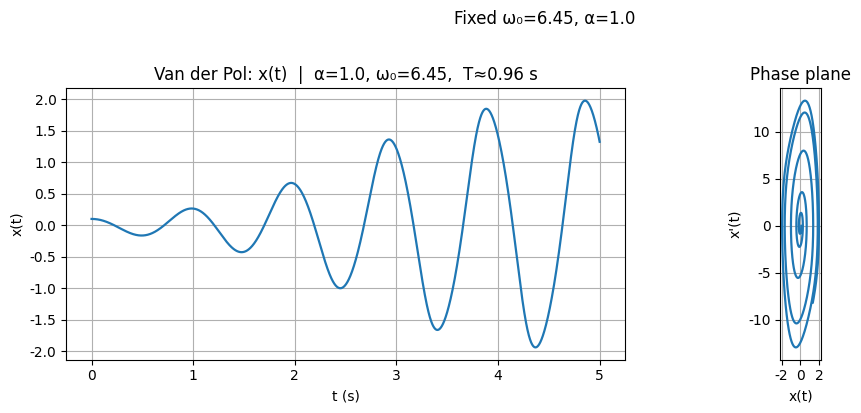

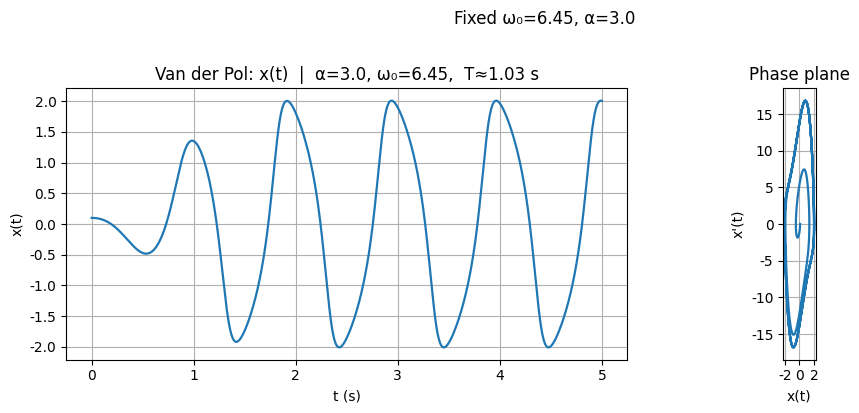

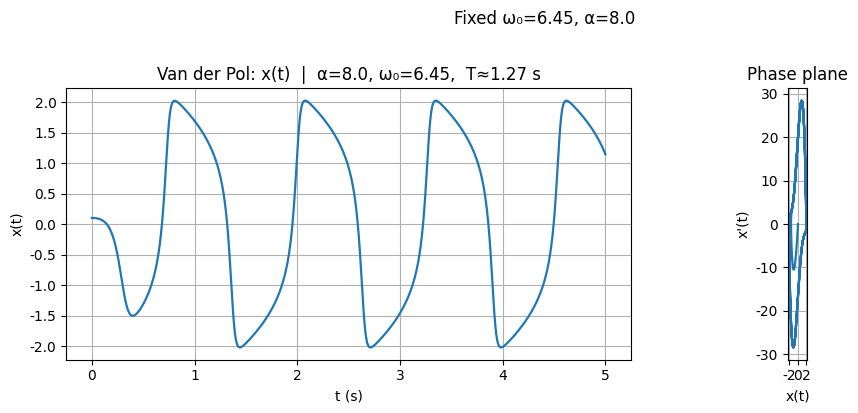

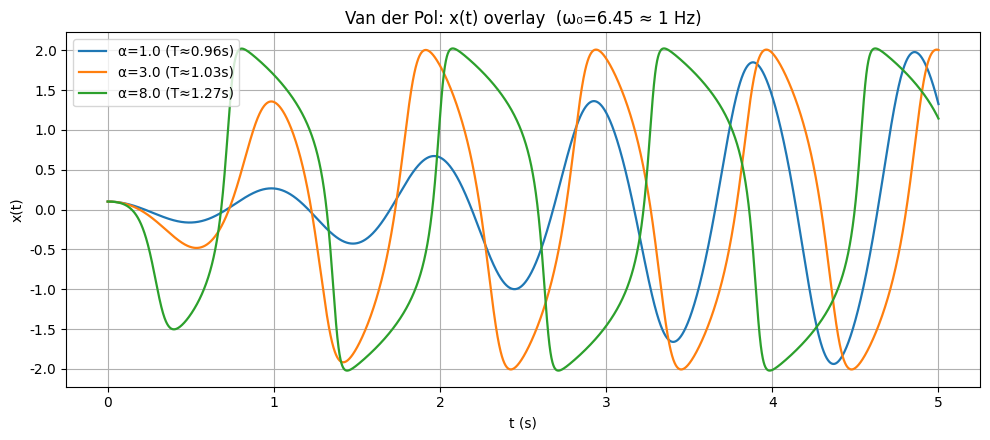

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# ----------------------------
# Van der Pol system
# x'' - 2*alpha*(1 - x^2)*x' + w0^2*x = 0
# -> x' = v,  v' = 2*alpha*(1 - x**2)*v - (w0**2)*x
# ----------------------------
def vdp_system(t, y, alpha, w0):
    x, v = y
    return [v, 2*alpha*(1 - x**2)*v - (w0**2)*x]

# ======= chosen parameters (≈1 s period; increasing alpha -> faster transient) =======
w0 = 6.45 #2*np.pi
parameter_sets = [
    (1.0, w0),   # near-sinusoidal, slower settling
    (3.0, w0),   # AP-like, ~100 ms settling
    (8.0, w0),   # relaxation, ~10–50 ms settling (stiff)
]

# time window and sampling
t_span = (0.0, 5.0)                       # 5 s shows many cycles
t_eval = np.linspace(*t_span, 5000)       # dense sampling

# initial conditions
x0, v0 = 0.1, 0.0

plt.rcParams["axes.unicode_minus"] = False

period_est = {}

# =========================
# plots per (alpha, w0)
# =========================
for alpha, w0 in parameter_sets:
    method = "RK45" if alpha <= 3 else "Radau"  # stiff when alpha is large
    sol = solve_ivp(
        vdp_system, t_span, [x0, v0],
        args=(alpha, w0), t_eval=t_eval,
        method=method, rtol=1e-7, atol=1e-9, max_step=0.01
    )
    t = sol.t
    x, v = sol.y

    # --- period estimate from peaks after a transient cut ---
    cut = int(0.4*len(t)) if alpha <= 3 else int(0.6*len(t))
    pk, _ = find_peaks(x[cut:])
    T = np.nan
    if len(pk) >= 2:
        times = t[cut:][pk]
        T = np.mean(np.diff(times))
    period_est[(alpha, w0)] = T

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # x(t)
    axes[0].plot(t, x, lw=1.6)
    axes[0].set_xlabel("t (s)")
    axes[0].set_ylabel("x(t)")
    title_T = f",  T≈{T:.2f} s" if np.isfinite(T) else ""
    axes[0].set_title(f"Van der Pol: x(t)  |  α={alpha}, ω₀={w0:.2f}{title_T}")
    axes[0].grid(True)

    # phase plane
    axes[1].plot(x, v, lw=1.6)
    axes[1].set_xlabel("x(t)")
    axes[1].set_ylabel("x'(t)")
    axes[1].set_title("Phase plane")
    axes[1].grid(True)
    axes[1].set_aspect("equal", "box")

    fig.suptitle(f"Fixed ω₀={w0:.2f}, α={alpha}", y=1.02)
    plt.tight_layout()
    plt.savefig(f"vdp_fixed_w0_{w0:.2f}_alpha_{alpha}.png", dpi=200, bbox_inches="tight")
    plt.show()

# =========================
# overlay of x(t) for all α
# =========================
plt.figure(figsize=(10, 4.5))
for alpha, w0 in parameter_sets:
    method = "RK45" if alpha <= 3 else "Radau"
    sol = solve_ivp(
        vdp_system, t_span, [x0, v0],
        args=(alpha, w0), t_eval=t_eval,
        method=method, rtol=1e-7, atol=1e-9, max_step=0.01
    )
    t = sol.t
    x = sol.y[0]
    T = period_est.get((alpha, w0), np.nan)
    label = f"α={alpha} (T≈{T:.2f}s)" if np.isfinite(T) else f"α={alpha}"
    plt.plot(t, x, lw=1.6, label=label)

plt.xlabel("t (s)")
plt.ylabel("x(t)")
plt.title(f"Van der Pol: x(t) overlay  (ω₀={w0:.2f} ≈ 1 Hz)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("vdp_overlay_1Hz.png", dpi=200, bbox_inches="tight")
plt.show()


# Comparing FitzHugh-Nagumo and Van der Pol Models:

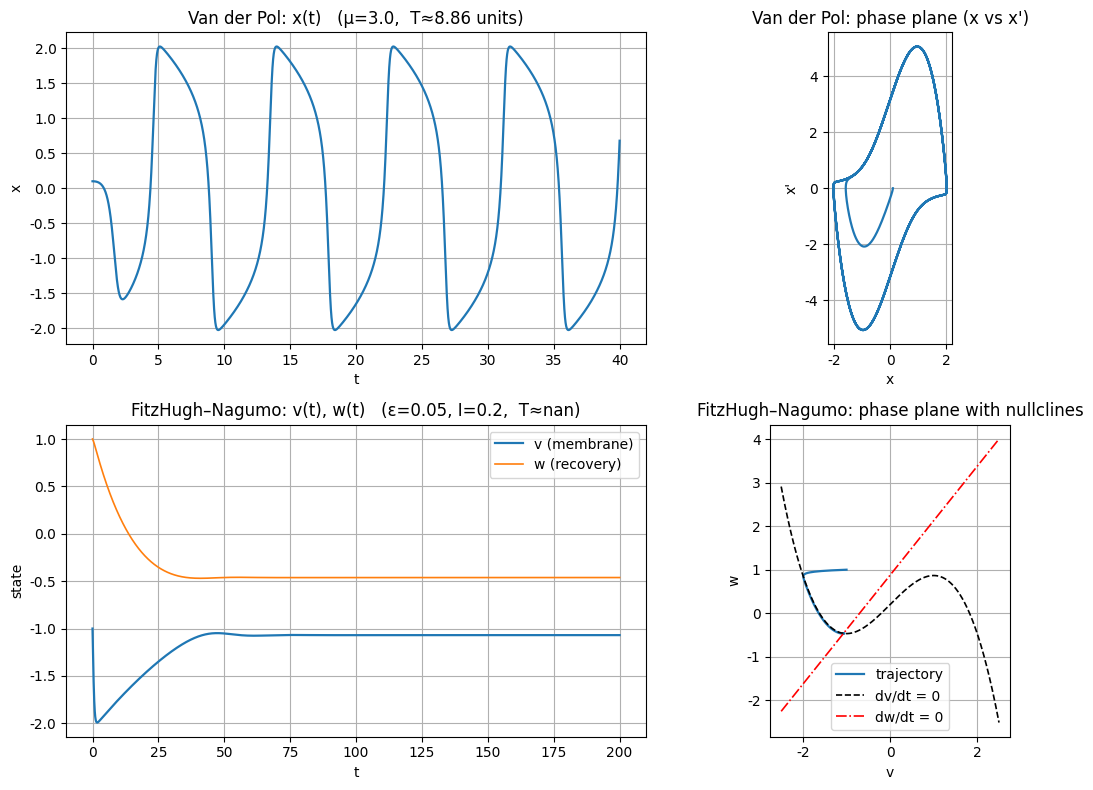

=== Quick comparison ===
Van der Pol period ~ 8.86 time units; relaxation strength set by μ=3.0.
FitzHugh–Nagumo period ~ nan time units; spike sharpness set by ε=0.05, drive by I=0.2.


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# ==============================
# Van der Pol oscillator (VdP)
# x'' - mu*(1 - x^2)*x' + x = 0
# -> x' = v
# -> v' = mu*(1 - x**2)*v - x
# ==============================
def vdp(t, y, mu):
    x, v = y
    return [v, mu*(1 - x**2)*v - x]

# ==========================================
# FitzHugh–Nagumo (FHN)
# dv/dt = v - v^3/3 - w + I
# dw/dt = eps * (v + a - b*w)
# ==========================================
def fhn(t, y, eps, a, b, I):
    v, w = y
    return [v - (v**3)/3 - w + I, eps*(v + a - b*w)]

# ----------------------------
# Helper: period estimation
# ----------------------------
def estimate_period(t, sig, cut_ratio=0.3, prom=0.1):
    cut = int(cut_ratio * len(t))
    pk, _ = find_peaks(sig[cut:], prominence=prom)
    if len(pk) >= 2:
        times = t[cut:][pk]
        return float(np.mean(np.diff(times)))
    return np.nan

# ==========================================================
# Parameter choices to get comparable oscillation periods
# (you can tweak slightly; these are good defaults)
# ==========================================================
# Van der Pol: moderate relaxation
mu = 3.0
t_span = (0.0, 40.0)
t_eval = np.linspace(*t_span, 8000)
x0, v0 = 0.1, 0.0

vdp_sol = solve_ivp(
    vdp, t_span, [x0, v0],
    args=(mu,), t_eval=t_eval,
    method="Radau", rtol=1e-7, atol=1e-9, max_step=0.02
)
t_vdp = vdp_sol.t
x_vdp, v_vdp = vdp_sol.y
T_vdp = estimate_period(t_vdp, x_vdp, cut_ratio=0.4, prom=0.15)

# FitzHugh–Nagumo: classic excitable regime with oscillation
a, b = 0.7, 0.8
eps = 0.05           # smaller -> stronger timescale separation (sharper spike)
I   = 0.2            # drive; raises cubic nullcline (oscillation if high enough)

t_span_fhn = (0.0, 200.0)   # FHN period is typically longer; give it more time
t_eval_fhn = np.linspace(*t_span_fhn, 10000)
v0, w0 = -1.0, 1.0

fhn_sol = solve_ivp(
    fhn, t_span_fhn, [v0, w0],
    args=(eps, a, b, I),
    t_eval=t_eval_fhn,
    method=("Radau" if eps < 0.05 else "RK45"),
    rtol=1e-7, atol=1e-9, max_step=0.02
)
t_fhn = fhn_sol.t
v_fhn, w_fhn = fhn_sol.y
T_fhn = estimate_period(t_fhn, v_fhn, cut_ratio=0.5, prom=0.2)

# =========================
# Plots: time & phase-plane
# =========================
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
# --- VdP time ---
axs[0,0].plot(t_vdp, x_vdp, lw=1.6)
axs[0,0].set_title(f"Van der Pol: x(t)   (μ={mu},  T≈{T_vdp:.2f} units)")
axs[0,0].set_xlabel("t"); axs[0,0].set_ylabel("x"); axs[0,0].grid(True)

# --- VdP phase ---
axs[0,1].plot(x_vdp, v_vdp, lw=1.6)
axs[0,1].set_title("Van der Pol: phase plane (x vs x')")
axs[0,1].set_xlabel("x"); axs[0,1].set_ylabel("x'"); axs[0,1].grid(True)
axs[0,1].set_aspect("equal","box")

# --- FHN time ---
axs[1,0].plot(t_fhn, v_fhn, lw=1.6, label="v (membrane)")
axs[1,0].plot(t_fhn, w_fhn, lw=1.2, label="w (recovery)")
axs[1,0].set_title(f"FitzHugh–Nagumo: v(t), w(t)   (ε={eps}, I={I},  T≈{T_fhn:.2f})")
axs[1,0].set_xlabel("t"); axs[1,0].set_ylabel("state"); axs[1,0].grid(True); axs[1,0].legend()

# --- FHN phase + nullclines ---
v_grid = np.linspace(-2.5, 2.5, 400)
w_nc1 = v_grid - (v_grid**3)/3 + I     # dv/dt=0
w_nc2 = (v_grid + a)/b                 # dw/dt=0
axs[1,1].plot(v_fhn, w_fhn, lw=1.6, label="trajectory")
axs[1,1].plot(v_grid, w_nc1, 'k--', lw=1.2, label="dv/dt = 0")
axs[1,1].plot(v_grid, w_nc2, 'r-.', lw=1.2, label="dw/dt = 0")
axs[1,1].set_title("FitzHugh–Nagumo: phase plane with nullclines")
axs[1,1].set_xlabel("v"); axs[1,1].set_ylabel("w"); axs[1,1].grid(True)
axs[1,1].set_aspect("equal","box"); axs[1,1].legend(loc="best")

plt.tight_layout()
plt.show()

# ============ Optional: quick text summary in console ============
print("=== Quick comparison ===")
print(f"Van der Pol period ~ {T_vdp:.2f} time units; relaxation strength set by μ={mu}.")
print(f"FitzHugh–Nagumo period ~ {T_fhn:.2f} time units; spike sharpness set by ε={eps}, drive by I={I}.")


## Comparing FitzHugh–Nagumo and Van der Pol Models

### Qualitative comparison of waveforms

- **Van der Pol oscillator (VdP)**  
  - State variable \(x(t)\) shows **self-sustained oscillations** whose amplitude is regulated by the nonlinear damping term.  
  - For large \(\alpha\), the waveform becomes a **relaxation oscillation**: a rapid jump followed by a slower return, mimicking an action-potential–like spike.
  - There is only **one observable state variable** (often interpreted as a generic “activation” variable).

- **FitzHugh–Nagumo (FHN) model**  
  - The membrane potential \(v(t)\) also exhibits **repetitive spikes**, but now accompanied by a slower **recovery variable** \(w(t)\).  
  - The spikes in \(v\) are followed by a gradual rise and decay in \(w\), representing **refractory and recovery processes**.  
  - The separation of time scales (small \(\varepsilon\)) makes the spike fast and the recovery slow, closely resembling real neuronal or cardiac action potentials.

### Phase-plane comparison

- **VdP phase plane \((x, \dot{x})\)**  
  - Trajectories spiral toward a **limit cycle**.  
  - For large \(\alpha\), the limit cycle is strongly distorted from a circle, giving a “loop” with sharp corners corresponding to the fast upstroke and downstroke of the relaxation oscillation.  

- **FHN phase plane \((v, w)\)**  
  - Trajectory also forms a **closed limit-cycle loop**, but now in the plane of **voltage vs. recovery**.  
  - The loop follows the familiar shape determined by the **cubic \(v\)-nullcline** and **approximately linear \(w\)-nullcline**.  
  - Motion is fast along the nearly vertical parts of the loop (spike upstroke/downstroke in \(v\)) and slow along the horizontal parts (recovery in \(w\)), highlighting the clear fast–slow structure of the model.

### Advantages of the FitzHugh–Nagumo model

- Separates the dynamics into a **fast variable** \(v\) and a **slow recovery variable** \(w\), which maps naturally onto physiological concepts (membrane potential vs. gating/recovery).  
- Captures **excitability, threshold behavior, and refractory periods** more explicitly than Van der Pol.  
- External current \(I\) provides a simple control over whether the system rests, fires single spikes, or produces repetitive spiking.

### Advantages of the Van der Pol model

- Mathematically **simpler** (single second-order equation) and closely related to the linear oscillator, which makes it easier to analyze analytically.  
- Still produces **self-sustained, amplitude-regulated oscillations** and relaxation-like spikes for large \(\alpha\).  
- Useful as a generic nonlinear oscillator model for studying qualitative phenomena (limit cycles, bifurcations) without committing to detailed biophysical interpretation.

### Limitations

- **Van der Pol oscillator**
  - Lacks an explicit recovery variable, so **refractory dynamics and conductance-like effects** are only implicit in the nonlinear damping.  
  - Mapping parameters directly to physiological quantities is difficult; it is primarily a **phenomenological model**.

- **FitzHugh–Nagumo model**
  - Still a **reduced** description; it simplifies many ionic currents into a single recovery variable and does not capture all features of real neurons or cardiac cells.  
  - More parameters (\(\varepsilon, a, b, I\)) and slightly more complex dynamics than Van der Pol.




Both models generate **limit-cycle oscillations** and can qualitatively reproduce action-potential–like spikes.  
However, the **FitzHugh–Nagumo model** better represents the **biophysical structure** of excitable cells by separating fast membrane dynamics from slower recovery, while the **Van der Pol oscillator** serves as a simpler, more abstract nonlinear oscillator that is easier to analyze but less directly tied to underlying physiology.
